<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**


## **Цель работы**


Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**


1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса (Время, затрачиваемое моделью на формирование предсказания. Измеряется путём усреднения результатов на нескольких тысячах изображений)
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [3]:
selected_classes = [0, 8, 9]
class_names_original = {0: "airplane", 8: "ship", 9: "truck"}
new_class_names = ["airplane", "ship", "truck"]

train_mask = np.isin(y_train.flatten(), selected_classes)
test_mask = np.isin(y_test.flatten(), selected_classes)

x_train = x_train[train_mask]
y_train = y_train[train_mask]
x_test = x_test[test_mask]
y_test = y_test[test_mask]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(15000, 32, 32, 3) (15000, 1)
(3000, 32, 32, 3) (3000, 1)


In [4]:
label_map = {0: 0, 8: 1, 9: 2}

y_train = np.array([label_map[int(y)] for y in y_train]).reshape(-1, 1)
y_test = np.array([label_map[int(y)] for y in y_test]).reshape(-1, 1)

print(np.unique(y_train), np.unique(y_test))

[0 1 2] [0 1 2]


/tmp/ipykernel_3830/3147075411.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_train = np.array([label_map[int(y)] for y in y_train]).reshape(-1, 1)
/tmp/ipykernel_3830/3147075411.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_test = np.array([label_map[int(y)] for y in y_test]).reshape(-1, 1)


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Train:", x_train.shape, y_train.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (12000, 32, 32, 3) (12000, 1)
Val: (3000, 32, 32, 3) (3000, 1)
Test: (3000, 32, 32, 3) (3000, 1)


/tmp/ipykernel_3830/2060421951.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(new_class_names[int(y_train[i])])


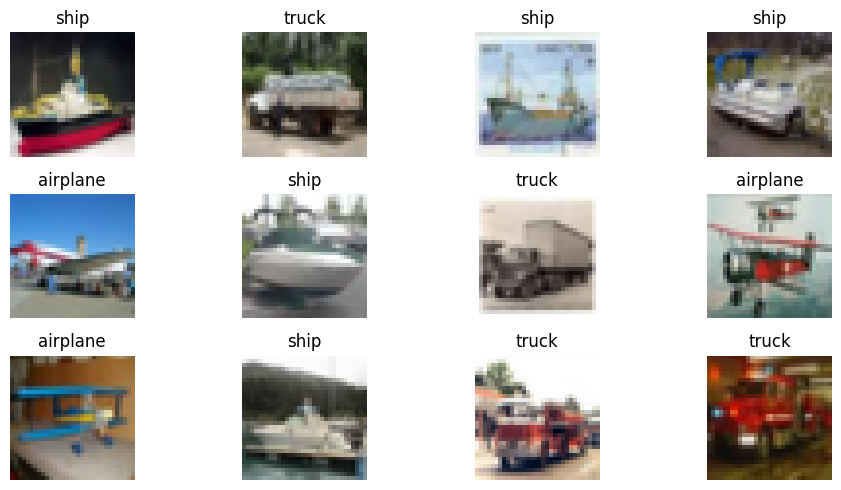

In [6]:
plt.figure(figsize=(10, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(new_class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
model_1 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6532 - loss: 0.7659 - val_accuracy: 0.7217 - val_loss: 0.6486
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7732 - loss: 0.5574 - val_accuracy: 0.7837 - val_loss: 0.5405
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8161 - loss: 0.4676 - val_accuracy: 0.8013 - val_loss: 0.5005
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8418 - loss: 0.4128 - val_accuracy: 0.8270 - val_loss: 0.4354
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8528 - loss: 0.3789 - val_accuracy: 0.8277 - val_loss: 0.4543
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8698 - loss: 0.3439 - val_accuracy: 0.8377 - val_loss: 0.4157
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8803 - loss: 0.3174 - val_accuracy: 0.8473 - val_loss: 0.3935
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8924 - loss: 0.2883 - val_accuracy: 0

In [8]:
model_2 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6198 - loss: 0.8087 - val_accuracy: 0.7370 - val_loss: 0.6287
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7757 - loss: 0.5453 - val_accuracy: 0.7743 - val_loss: 0.5504
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8381 - loss: 0.4100 - val_accuracy: 0.8460 - val_loss: 0.4126
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8769 - loss: 0.3223 - val_accuracy: 0.8573 - val_loss: 0.3604
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8977 - loss: 0.2678 - val_accuracy: 0.8610 - val_loss: 0.3577
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9136 - loss: 0.2241 - val_accuracy: 0.8793 - val_loss: 0.3154
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9345 - loss: 0.1762 - val_accuracy: 0.8840 - val_loss: 0.3295
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9486 - loss: 0.1419 - val_accuracy: 0

In [9]:
model_3 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.5797 - loss: 0.9308 - val_accuracy: 0.3333 - val_loss: 2.1993
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6941 - loss: 0.7025 - val_accuracy: 0.4903 - val_loss: 1.4075
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7507 - loss: 0.6030 - val_accuracy: 0.8033 - val_loss: 0.5181
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7869 - loss: 0.5339 - val_accuracy: 0.8357 - val_loss: 0.4466
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8158 - loss: 0.4787 - val_accuracy: 0.7790 - val_loss: 0.5420
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8303 - loss: 0.4446 - val_accuracy: 0.8380 - val_loss: 0.4505
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8444 - loss: 0.4168 - val_accuracy: 0.8710 - val_loss: 0.3345
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8487 - loss: 0.4040 - val_accuracy: 

In [10]:
def evaluate_model(model, x_test, y_test, model_name):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = y_test.flatten()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

In [11]:
results = []
results.append(evaluate_model(model_1, x_test, y_test, "CNN_1"))
results.append(evaluate_model(model_2, x_test, y_test, "CNN_2"))
results.append(evaluate_model(model_3, x_test, y_test, "CNN_3"))

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1-score", ascending=False)
df_results

,Model,Accuracy,Precision,Recall,F1-score
1,CNN_2,0.884667,0.886233,0.884667,0.884183
0,CNN_1,0.866333,0.869597,0.866333,0.865989
2,CNN_3,0.857667,0.875024,0.857667,0.854475


In [12]:
best_model_name = df_results.iloc[0]["Model"]
best_model_name

'CNN_2'

In [13]:
if best_model_name == "CNN_1":
    best_model = model_1
elif best_model_name == "CNN_2":
    best_model = model_2
else:
    best_model = model_3

In [14]:
y_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=new_class_names))

              precision    recall  f1-score   support

    airplane       0.86      0.88      0.87      1000
        ship       0.92      0.83      0.87      1000
       truck       0.88      0.95      0.91      1000

    accuracy                           0.88      3000
   macro avg       0.89      0.88      0.88      3000
weighted avg       0.89      0.88      0.88      3000



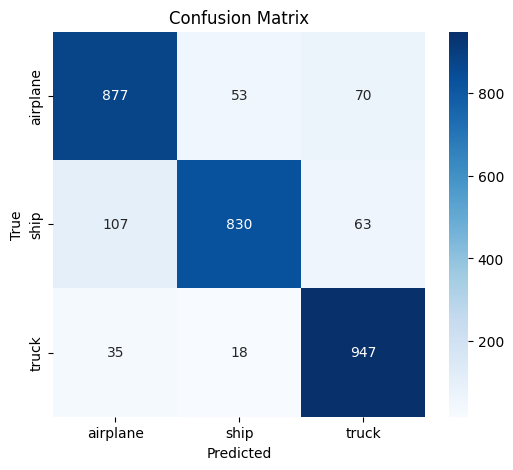

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names,
            yticklabels=new_class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [16]:
best_model.save("best_classification_model.h5")

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
best_model.save("/content/drive/MyDrive/best_classification_model.h5")
df_results.to_csv("/content/drive/MyDrive/metrics_results.csv", index=False)

---

### **Раздел 2. Развертывание API**


1. Создать FastAPI приложение для обработки запросов с изображениями
2. Реализовать предобработку загружаемых изображений
3. Реализовать эндпоинт для классификации изображений
4. Добавить возврат предсказанного класса и вероятностей по всем классам
5. Создать файл requirements.txt с необходимыми зависимостями
6. Развернуть API на любом сервере с доступом из глобальной сети

#### **Инструкция по развёртыванию на Render.com**



**Шаги:**

1. **Репозиторий проекта:**
   - Создайте репозиторий на GitHub, содержащий файлы `main.py`, `requirements.txt`, `best_classification_model` и `scaler.pkl` (при наличии).

2. **Регистрация на Render.com:**
   - Зарегистрируйтесь на [Render.com](https://render.com/).

3. **Создание нового веб-сервиса:**
   - В панели управления Render.com создайте новый веб-сервис, связав его с вашим репозиторием.

4. **Настройка версии Python:**
   - В разделе **Environment Variables** (Переменные окружения) добавьте новую переменную:
     - **Key (Ключ):** `PYTHON_VERSION`
     - **Value (Значение):** `3.12.1`
   - Это позволит Render.com использовать указанную версию Python при сборке и запуске приложения.

5. **Настройка сервиса:**
   - Укажите команду запуска приложения: `uvicorn main:app --host 0.0.0.0 --port $PORT`.
   - Убедитесь, что в `requirements.txt` перечислены все необходимые зависимости.

6. **Развёртывание:**
   - Запустите процесс развёртывания и дождитесь его завершения.
   - После успешного развёртывания ваш API будет доступен по выделенному адресу.

#### **Инструкция по развёртыванию Hugging Face Spaces (если возникли пролемы с доступом к Render.com)**


**Шаги:**

1. **Регистрация:**
   - Зарегистрируйтесь на [huggingface.co](https://huggingface.co) (бесплатно, без карты).
   - Подтвердите e-mail.

2. **Создание нового Space:**
   - На главной странице нажмите на аватар → **New Space**.
   - Заполните поля:
     - **Space name:** `имя_проекта_backend`.
     - **License:** `mit` (или любая на ваш выбор).
     - **SDK:** выбрать **Docker** → **Blank**.
     - **Visibility:** `Public`.
     - **Hardware:** `CPU basic · 2 vCPU · 16 GB · FREE`.

3. **Push репозитория в Hugging Face:**
   - После создания Space Hugging Face даст адрес Git-репозитория вида `https://huggingface.co/spaces/ВАШ_USERNAME/california-regression`.
   - Добавьте его как удалённый репозиторий в ваш локальный проект:
   ```bash
   git remote add hf https://huggingface.co/spaces/ВАШ_USERNAME/ВАШ_РЕПОЗИТОРИЙ
   git push hf main
   ```
   - При push потребуется логин Hugging Face и **Access Token** (создаётся в Settings → Access Tokens с правом `write`).

4. **Автоматическая сборка:**
   - Hugging Face автоматически обнаружит `Dockerfile` и запустит сборку.
   - Процесс сборки занимает **5–10 минут** (установка TensorFlow — самая долгая часть).
   - Статус можно отслеживать на вкладке **Logs** в интерфейсе Space.

5. **Получение публичного URL:**
   - После успешного деплоя API доступен по адресу:
     ```
     https://ВАШ_USERNAME-ИМЯ-ПРОЕКТА.hf.space/predict
     ```
   - Этот URL работает 24/7 без усыпления, в отличие от бесплатных тарифов Render.com.

---

**Структура проекта для развёртывания на Hugging Face**

```
main.py
requirements.txt
Dockerfile
README.md
best_classification_model.h5
```

---

**Содержимое Dockerfile**


```dockerfile
# Используем официальный образ Python 3.12 (slim-версия для экономии места)
FROM python:3.12-slim

# Устанавливаем рабочую директорию внутри контейнера
WORKDIR /app

# Копируем файл зависимостей
COPY requirements.txt .

# Устанавливаем зависимости
RUN pip install --no-cache-dir --upgrade pip && \
    pip install --no-cache-dir -r requirements.txt

# Копируем все файлы проекта в контейнер
COPY . .

# Открываем порт 7860 (стандартный порт для Hugging Face Spaces)
EXPOSE 7860

# Команда запуска приложения
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
```

---


#### **Ответ:**

**ВАША ССЫЛКА НА БЭКЕНД**

---

### **Раздел 3. Создание интерфейса на Streamlit**



1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### **Ответ:**

**ВАША ССЫЛКА НА ФРОНТЭНД**

---

### **Раздел 4. Документация и публикация проекта**


1. Создать GitHub-репозиторий со структурой:
   - Модели (сохраненная лучшая модель)
   - API (код и зависимости)
   - Интерфейс (код Streamlit-приложения)
   - Документация (README.md)
   - Требования (requirements.txt)
2. Добавить в README.md:
   - Описание проекта и используемого датасета
   - Описание сравниваемых моделей
   - Таблицу с результатами сравнения моделей
   - Визуализации результатов
   - Инструкции по локальному развертыванию
   - Ссылки на развернутый API и Streamlit-приложение
   - Примеры использования API
3. Предоставить ссылки на:
   - GitHub-репозиторий
   - Публичный API для отправки POST-запросов
   - Streamlit-интерфейс для взаимодействия с моделью

#### **Ответ:**

**ВАША ССЫЛКА НА РЕПОЗИТОРИЙ С ПОДРОБНОЙ ДОКУМЕНТАЦИЕЙ**

---

#### **Пример**

- **GitHub-репозиторий:** https://github.com/Alexandre77777/dpo_classification.git

- **Публичный API для отправки POST-запросов:** https://dpo-classification.onrender.com/predict/

- **Streamlit-интерфейс для взаимодействия с моделью:** https://dpo-classification.streamlit.app/
